# Power Normal Distribution

The **Power Normal distribution** is a generalisation of the Normal distribution through a power (Box-Cox-like) transformation. When the shape parameter p=1, it reduces to the standard Normal. It provides additional flexibility to model skewed data that is "close to" Normal.

| Property | Value |
|---|---|
| **Parameters** | $p$ (shape/power, $p > 0$), $\mu$ (location), $\sigma$ (scale) |
| **PDF** | $\displaystyle f(x) = \frac{p\,\phi(z)\,[\Phi(z)]^{p-1}}{\sigma}$, where $z = (x-\mu)/\sigma$ |
| **CDF** | $F(x) = [\Phi(z)]^p$ |
| **Special case** | $p=1 \to$ Standard Normal |
| **Shape effect** | $p < 1$: right-skewed; $p = 1$: Normal; $p > 1$: left-skewed |
| **Use cases** | Reliability analysis; alternative to Box-Cox transform |
| **Note** | Not widely supported in standard software — use scipy `powernorm` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Power Normal Distribution

### Panel 1 — PDF: Shape $p$ Controls Skewness
Each curve shows the **PDF** $f(x) = p\,\phi(z)[\Phi(z)]^{p-1}/\sigma$ for different $p$. At $p=1$ it is the standard Normal. Values $p < 1$ produce right-skew; values $p > 1$ produce left-skew.

### Panel 2 — CDF: $F(x) = [\Phi(z)]^p$
The **CDF** $F(x) = [\Phi(z)]^p$ shifts as $p$ changes. For $p > 1$ the distribution accumulates probability more quickly at low values (left shift); for $p < 1$ the mass shifts to the right.

### Panel 3 — MLE Fit
A sample of 300 Power Normal observations (true $p=0.5$) is fitted via MLE. The fitted blue curve closely matches the true grey dashed curve, demonstrating the effectiveness of MLE for this distribution.


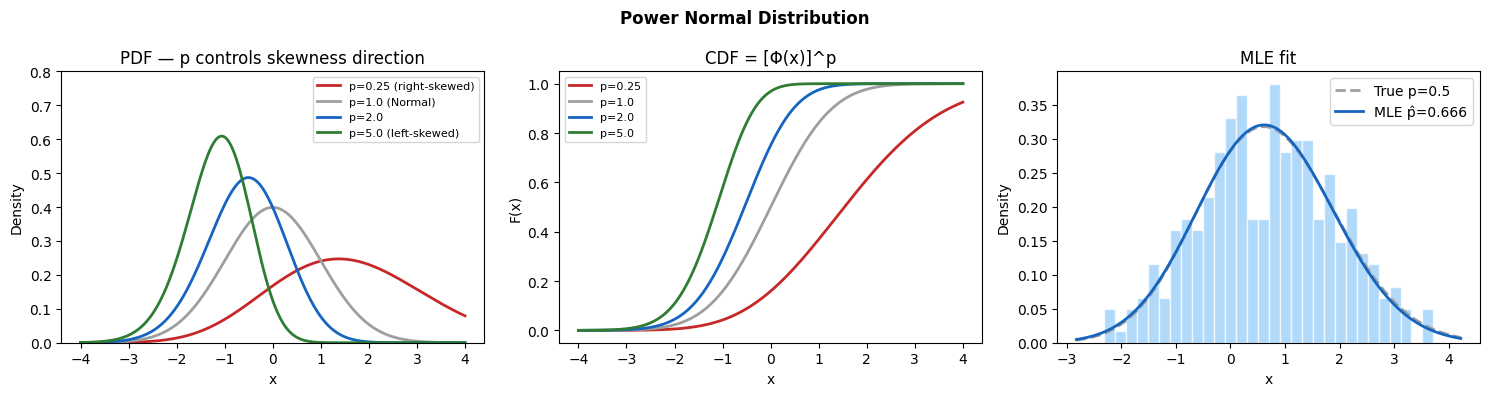

True p=0.5, MLE p̂=0.666
Skewness: true=0.137, sample=0.015


In [2]:
# scipy powernorm: c=p (shape parameter)
x = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Power Normal Distribution', fontsize=12, fontweight='bold')

# PDF
for p, color, label in [(0.25, '#C62828', 'p=0.25 (right-skewed)'),
                         (1.0,  '#9E9E9E', 'p=1.0 (Normal)'),
                         (2.0,  '#1565C0', 'p=2.0'),
                         (5.0,  '#2E7D32', 'p=5.0 (left-skewed)')]:
    axes[0].plot(x, stats.powernorm(c=p).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — p controls skewness direction')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=8)

# CDF
for p, color, label in [(0.25, '#C62828', 'p=0.25'), (1.0, '#9E9E9E', 'p=1.0'),
                         (2.0, '#1565C0', 'p=2.0'), (5.0, '#2E7D32', 'p=5.0')]:
    axes[1].plot(x, stats.powernorm(c=p).cdf(x), color=color, linewidth=2, label=label)
axes[1].set_title('CDF = [Φ(x)]^p')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# MLE fit to skewed data
np.random.seed(42)
true_p = 0.5
sample = stats.powernorm(c=true_p).rvs(300)
p_fit, loc_fit, scale_fit = stats.powernorm.fit(sample)
x_fit = np.linspace(sample.min()-0.5, sample.max()+0.5, 300)

axes[2].hist(sample, bins=30, density=True, color='#90CAF9', edgecolor='white', alpha=0.7)
axes[2].plot(x_fit, stats.powernorm(c=true_p).pdf(x_fit),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True p={true_p}')
axes[2].plot(x_fit, stats.powernorm(c=p_fit, loc=loc_fit, scale=scale_fit).pdf(x_fit),
             color='#1565C0', linewidth=2, label=f'MLE p̂={p_fit:.3f}')
axes[2].set_title('MLE fit')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"True p={true_p}, MLE p̂={p_fit:.3f}")
print(f"Skewness: true={stats.powernorm(c=true_p).stats('s'):.3f}, "
      f"sample={stats.skew(sample):.3f}")

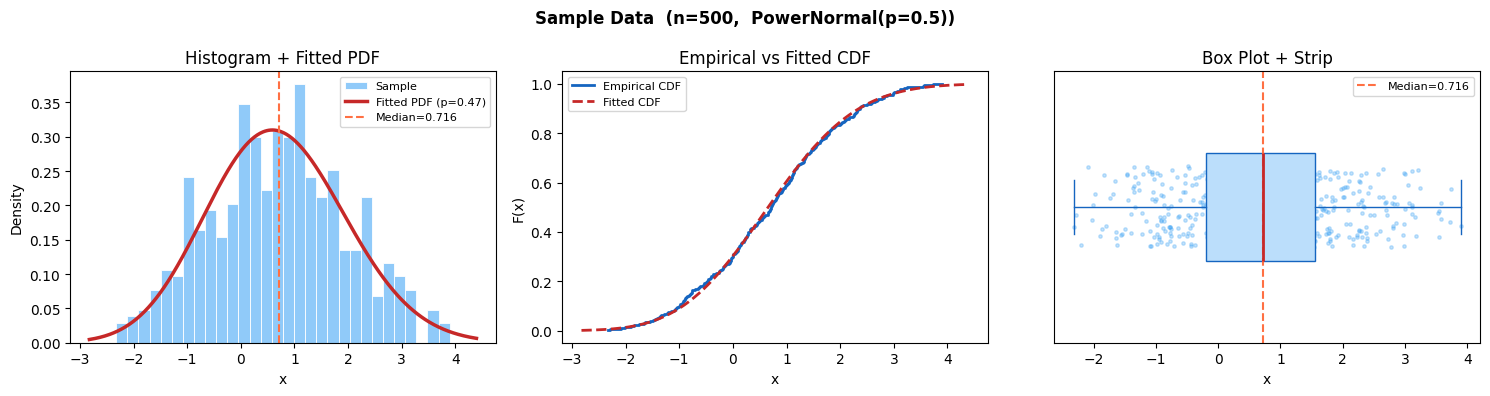

n=500  mean=0.6906  median=0.7160  std=1.2814  skew=0.0533  kurtosis=-0.5077


In [3]:
# Sample data plots — PowerNormal(p=0.5)
np.random.seed(42)
sample_d = stats.powernorm.rvs(c=0.5, size=500)
c_hat, loc_hat, scale_hat = stats.powernorm.fit(sample_d)
x_fit = np.linspace(sample_d.min() - 0.5, sample_d.max() + 0.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  PowerNormal(p=0.5))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.powernorm(c_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (p={c_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.powernorm(c_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **p=1** | Reduces to standard Normal |
| **p < 1** | Right-skewed — tail extends to the right |
| **p > 1** | Left-skewed — distribution shifts left |
| **CDF formula** | $F(x) = [\Phi(x)]^p$ — elegant power of the Normal CDF |
| **Hazard** | Monotonically increasing for all $p$ — suitable for wear-out reliability |
| **Alternative** | Box-Cox transformation is often preferred (more interpretable parameter) |
| **Software** | scipy `powernorm`; not in R base or Excel |
